In [74]:
import h5py
import numpy as np
import pandas as pd
import random
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import corner

from scipy import stats
from astroML.utils import completeness_contamination
from astroML.classification import GMMBayes

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.utils import resample

from sklearn.metrics import (
    accuracy_score, 
    recall_score, 
    precision_score, 
    roc_curve, 
    roc_auc_score, 
    auc, 
    confusion_matrix, 
    precision_score, 
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report

Can a computern learn if we're going to detect a GW?

In [75]:
with h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r') as file:
    
    keys = list(file.keys())
    print(keys)
    
    data = {}
    for key in keys:
        data[key] = file[key][:]

total_samples = len(data['det'])
print (f"Total samples:{total_samples}")

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']
Total samples:20000000


In [76]:
# Possibility to do downsampling
N_samples = total_samples // 100

idx = np.random.choice(total_samples, N_samples, replace=False)

par_keys = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'ra', 'iota', 'psi', 'z'] # remove snr
lab_keys = ['det']

# Create X and y to perform split
X = np.stack([data[k][idx] for k in par_keys], axis=1)
y = data['det'][idx].astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=52)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


print (f"number of detectable samples in the training (1): {np.sum(y_train==1)}")
print (f"number of non-detectable samples in the training (0): {np.sum(y_train==0)}")



number of detectable samples in the training (1): 20166
number of non-detectable samples in the training (0): 119834


Corner plot of training data

In [ ]:
figure = corner.corner(X_train, labels=par_keys, plot_datapoints=False, plot_density=False, fill_contours=True)
axes = np.array(figure.axes).reshape(len(par_keys), len(par_keys))

# Do again a downsampling (only for the plot)
n_plot = min(len(X_train), X_train.shape[0] //100)
plot_idx = np.random.choice(len(X_train), n_plot, replace=False)
X_plot = X_train[plot_idx]
y_plot = y_train[plot_idx]

for i in range(len(par_keys)):
    for j in range(i):
        ax = axes[i, j]
    
        ax.scatter(X_plot[y_plot == 0, j], X_plot[y_plot == 0, i], 
                   color="blue", s=1, alpha=0.3, label="Not Det" if i==1 and j==0 else "")
        ax.scatter(X_plot[y_plot == 1, j], X_plot[y_plot == 1, i], 
                   color="red", s=1, alpha=0.3, label="Det" if i==1 and j==0 else "")

plt.show()

Print the correlation matrix

In [ ]:
df_train = pd.DataFrame(X_train, columns=par_keys) 
corr_matrix = df_train.corr()  #(using Pearson coeff.)
print("Correlation matrix:")
print(corr_matrix)

Correlation matrix:
           mtot         q     chi1x     chi1y     chi1z     chi2x     chi2y  \
mtot   1.000000  0.000317  0.002315 -0.002628  0.000810  0.003968  0.002143   
q      0.000317  1.000000 -0.000561 -0.000146 -0.000333  0.000483  0.000949   
chi1x  0.002315 -0.000561  1.000000 -0.000452 -0.000122 -0.002284  0.002456   
chi1y -0.002628 -0.000146 -0.000452  1.000000  0.001512  0.000623 -0.002016   
chi1z  0.000810 -0.000333 -0.000122  0.001512  1.000000  0.003079  0.001613   
chi2x  0.003968  0.000483 -0.002284  0.000623  0.003079  1.000000 -0.002717   
chi2y  0.002143  0.000949  0.002456 -0.002016  0.001613 -0.002717  1.000000   
chi2z  0.004321  0.000141  0.000849 -0.003775 -0.003733 -0.001595 -0.001479   
dec   -0.005988 -0.002574  0.002080  0.001698  0.003267  0.000414 -0.000142   
ra     0.003181 -0.001587 -0.001031  0.000074  0.000942  0.000089  0.001008   
iota   0.001505 -0.002051  0.005009  0.005309 -0.003516  0.000755 -0.000316   
psi   -0.000358  0.003501 -0.001

Data are quite uncorrelated. Start with naive gaussian bayes classifier using single feature

Single Feature used: mtot, AUC: 0.602
Single Feature used: q, AUC: 0.546
Single Feature used: chi1x, AUC: 0.505
Single Feature used: chi1y, AUC: 0.502
Single Feature used: chi1z, AUC: 0.542
Single Feature used: chi2x, AUC: 0.498
Single Feature used: chi2y, AUC: 0.489
Single Feature used: chi2z, AUC: 0.510
Single Feature used: dec, AUC: 0.502
Single Feature used: ra, AUC: 0.508
Single Feature used: iota, AUC: 0.578
Single Feature used: psi, AUC: 0.501
Single Feature used: z, AUC: 0.971


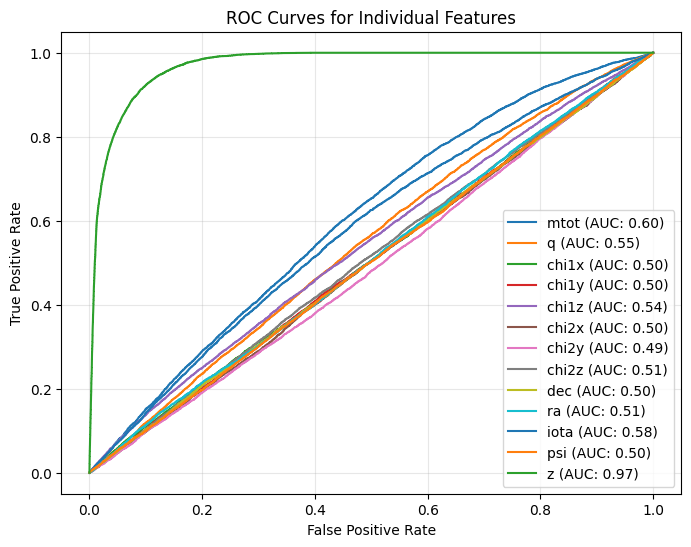

In [ ]:
gnb = GaussianNB()

auc_scores_gaus = []

features = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'ra', 'iota', 'psi', 'z']

# Roc for individual features
plt.figure(figsize=(8, 6))

for i in range(X_train.shape[1]):

    gnb.fit(X_train[:, i:i+1], y_train)

    y_prob = gnb.predict_proba(X_test[:, i:i+1])[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    auc_scores_gaus.append(auc_score)
    
    print(f"Single Feature used: {features[i]}, AUC: {auc_score:.3f}")
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{features[i]} (AUC: {auc_score:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Individual Features")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

 Now compute the Precision Recall curve for individual features (since non_det>det) it is a more accurate satistic to evaluate classificator 

Single Feature used: mtot, AP Score: 0.185
Single Feature used: q, AP Score: 0.161
Single Feature used: chi1x, AP Score: 0.150
Single Feature used: chi1y, AP Score: 0.146
Single Feature used: chi1z, AP Score: 0.167
Single Feature used: chi2x, AP Score: 0.144
Single Feature used: chi2y, AP Score: 0.141
Single Feature used: chi2z, AP Score: 0.149
Single Feature used: dec, AP Score: 0.147
Single Feature used: ra, AP Score: 0.150
Single Feature used: iota, AP Score: 0.178
Single Feature used: psi, AP Score: 0.146
Single Feature used: z, AP Score: 0.839


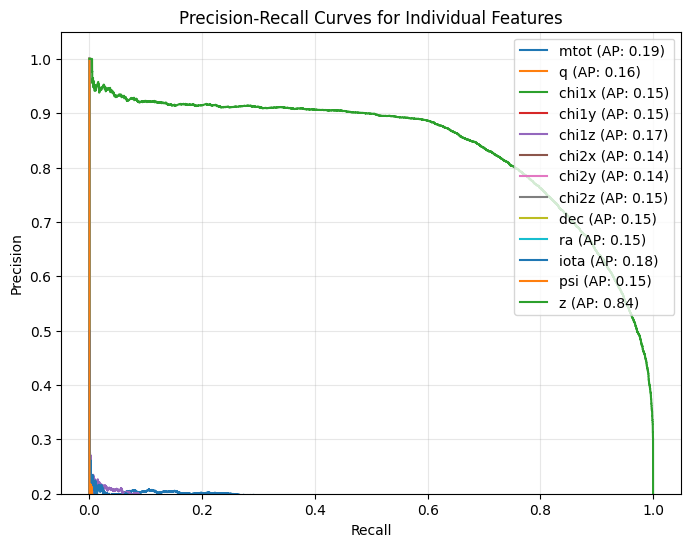

In [ ]:
ap_scores_gaus = []

plt.figure(figsize=(8, 6))

for i in range(X_train.shape[1]):

    # Train on just one feature at a time
    gnb.fit(X_train[:, i:i+1], y_train)

    y_prob = gnb.predict_proba(X_test[:, i:i+1])[:, 1]
    
    # Area Under the PR Curve (Average Precision)
    ap_score = average_precision_score(y_test, y_prob)
    ap_scores_gaus.append(ap_score)
    
    print(f"Single Feature used: {features[i]}, AP Score: {ap_score:.3f}")
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    
    # Plot
    plt.plot( recall, precision, label=f"{features[i]} (AP: {ap_score:.2f})")

plt.ylabel("Precision")
plt.xlabel("Recall")
plt.ylim(0.2,1.05)
plt.title("Precision-Recall Curves for Individual Features")
plt.legend(loc='upper right') # Moved to lower left because PR curves usually start high on the left
plt.grid(alpha=0.3)
plt.show()

Implement a decision tree classifier with cv to find best depth (use all feature togheter)

In [ ]:
#Perform downsampling to find the best decision tree depht

X_train_downsampled, y_train_downsampled = resample(
    X_train, y_train, 
    n_samples=N_samples//100, 
    stratify=y_train, 
    random_state=42
)

param_grid_dt = {'max_depth': range(2, 16)} 
dt = DecisionTreeClassifier(random_state=42)

# Grid search with 5-fold cross-validation to set the best depht
# We are optimizing for precision since the number of detectable samples is much smaller than the non-detectable 
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='average_precision', n_jobs=-1) 
grid_search_dt.fit(X_train_downsampled, y_train_downsampled)

val_scores_dt = grid_search_dt.cv_results_['mean_test_score']
depth_values = range(2, 16)





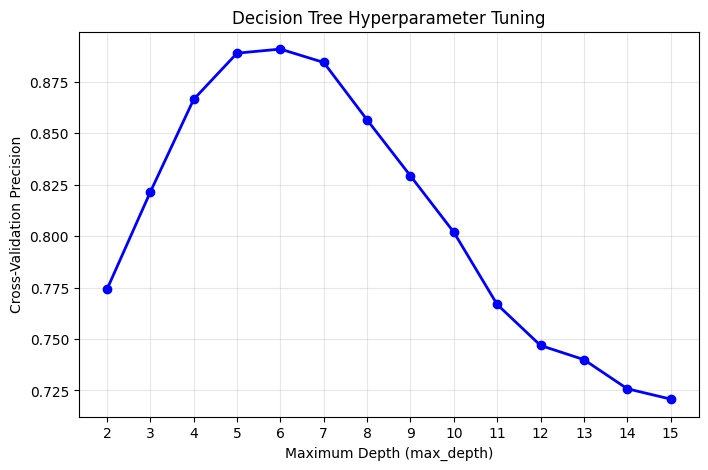

Best max_depth: 6
Best Mean Average Precision: 0.8909


In [ ]:
# Plot Grid Search Results
plt.figure(figsize=(8, 5))
plt.plot(depth_values, val_scores_dt, marker='o', color='blue', lw=2)
plt.xlabel('Maximum Depth (max_depth)')
plt.ylabel('Cross-Validation Precision')
plt.title('Decision Tree Hyperparameter Tuning')
plt.xticks(depth_values)
plt.grid(alpha=0.3)
plt.show()

# Extract the best depth and its corresponding score
best_depth = grid_search_dt.best_params_['max_depth']
best_score_dt = grid_search_dt.best_score_
print(f'Best max_depth: {best_depth}')
print(f'Best Mean Average Precision: {best_score_dt:.4f}')

Use the best model from the grid search to predict on the test set

In [ ]:
# Re train the best model on full dataset
best_dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=52)
best_dt_model.fit(X_train, y_train)

# Get probabilities for the positive class
y_prob_dt = best_dt_model.predict_proba(X_test)[:, 1]
y_pred_dt = best_dt_model.predict(X_test)

# Calculate Average Precision and the curve points
ap_score_dt = average_precision_score(y_test, y_prob_dt)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)

Plot Precision-Recall curve

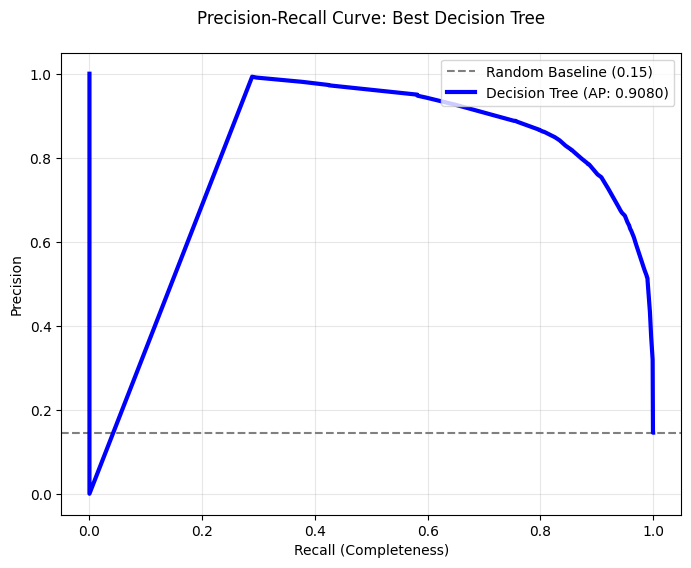

In [ ]:
plt.figure(figsize=(8, 6))

# Plot Random Baseline
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')

# Plot Decision Tree Curve
plt.plot(recall_dt, precision_dt, color='Blue', lw=3, 
         label=f'Decision Tree (AP: {ap_score_dt:.4f})')

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')

plt.title(f'Precision-Recall Curve: Best Decision Tree\n')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

Do a zoom to see the beahviour around 0 recall and 1 precision of the PR curve

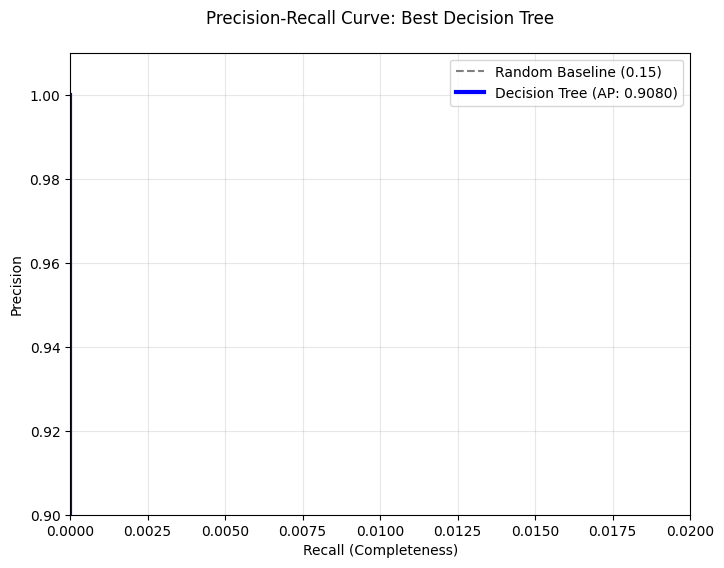

In [ ]:
plt.figure(figsize=(8, 6))

# Plot Random Baseline
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')

# Plot Decision Tree Curve
plt.plot(recall_dt, precision_dt, color='Blue', lw=3, 
         label=f'Decision Tree (AP: {ap_score_dt:.4f})')

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')
plt.xlim(0, 0.02)
plt.ylim(0.9,1.01)


plt.title(f'Precision-Recall Curve: Best Decision Tree\n')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

Plot the confusion matrix for two different threshold values (0.5 and 0.8)

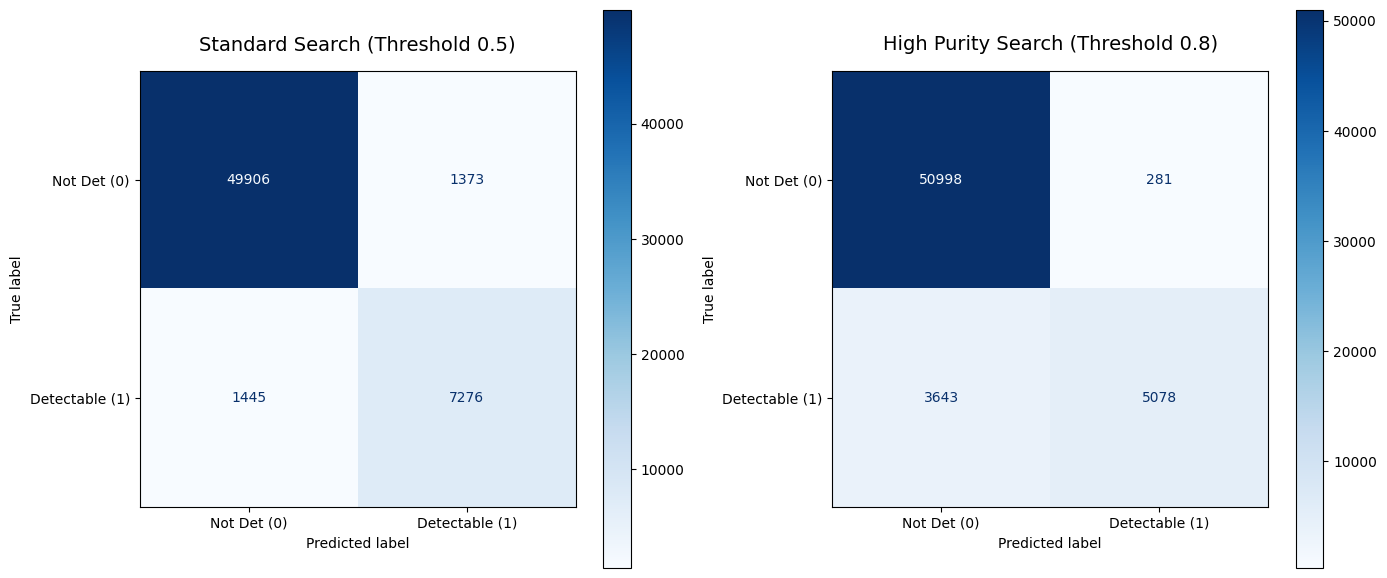

In [ ]:
y_pred_05_dt = (y_prob_dt > 0.5).astype(int)
y_pred_08_dt = (y_prob_dt > 0.8).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05_dt)
cm_08 = confusion_matrix(y_test, y_pred_08_dt)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_05 = ConfusionMatrixDisplay(
    confusion_matrix=cm_05, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)
disp_05.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title('Standard Search (Threshold 0.5)', fontsize=14, pad=15)
axes[0].grid(False)

disp_08 = ConfusionMatrixDisplay(
    confusion_matrix=cm_08, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)
disp_08.plot(cmap='Blues', values_format='d', ax=axes[1])
axes[1].set_title('High Purity Search (Threshold 0.8)', fontsize=14, pad=15)
axes[1].grid(False)

plt.tight_layout()
plt.show()

Now add bagging to see if the performance improves

In [ ]:

# To tune hyperparameters, use 1% of the training set 
X_train_down_bag, y_train_down_bag = resample(
    X_train, y_train, 
    n_samples=len(X_train) // 100, 
    stratify=y_train, 
    random_state=42
)


# Base decision tree with balanced weights
base_dt_for_bag = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Bagging
bagging_clf = BaggingClassifier(estimator=base_dt_for_bag, n_estimators=100, random_state=42, n_jobs=-1, max_samples=1.0)

param_grid_bag = {'estimator__max_depth': range(2, 16)} 

#CV
grid_search_bag = GridSearchCV(bagging_clf, param_grid_bag, cv=5, scoring='average_precision', verbose=1)
grid_search_bag.fit(X_train_down_bag, y_train_down_bag) 

val_scores_bag = grid_search_bag.cv_results_['mean_test_score']
depth_values = range(2, 16)

best_params_bag = grid_search_bag.best_params_
best_depth_bag = best_params_bag['estimator__max_depth']



Fitting 5 folds for each of 14 candidates, totalling 70 fits


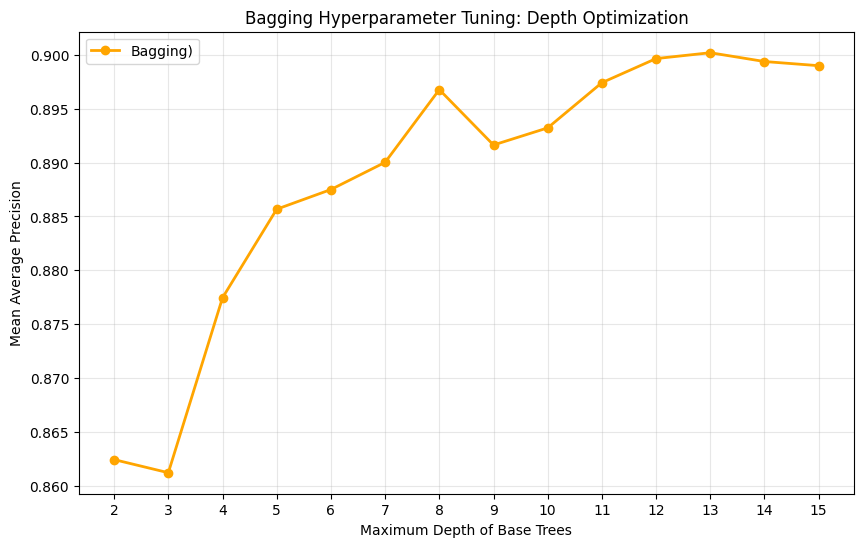

Best Parameters: {'estimator__max_depth': 13}
Best Average Precision: 0.9002


In [ ]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(depth_values, val_scores_bag, marker='o', lw=2, color='Orange', label='Bagging)')

plt.xlabel('Maximum Depth of Base Trees')
plt.ylabel('Mean Average Precision')
plt.title('Bagging Hyperparameter Tuning: Depth Optimization')
plt.xticks(depth_values)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Results
print(f"Best Parameters: {best_params_bag}")
print(f"Best Average Precision: {grid_search_bag.best_score_:.4f}")

In [ ]:
best_dt_model_for_bag = DecisionTreeClassifier(max_depth=best_depth_bag, random_state=52)
# Re train the best model on full dataset
best_bag_model = BaggingClassifier(estimator=best_dt_model_for_bag, n_estimators=100, random_state=42, n_jobs=-1, max_samples=1.0)
best_bag_model.fit(X_train, y_train)

y_prob_bag = best_bag_model.predict_proba(X_test)[:, 1]
y_pred_bag = best_bag_model.predict(X_test)

ap_score_bag = average_precision_score(y_test, y_prob_bag)
precision, recall, _ = precision_recall_curve(y_test, y_prob_bag)





Plot PR curve

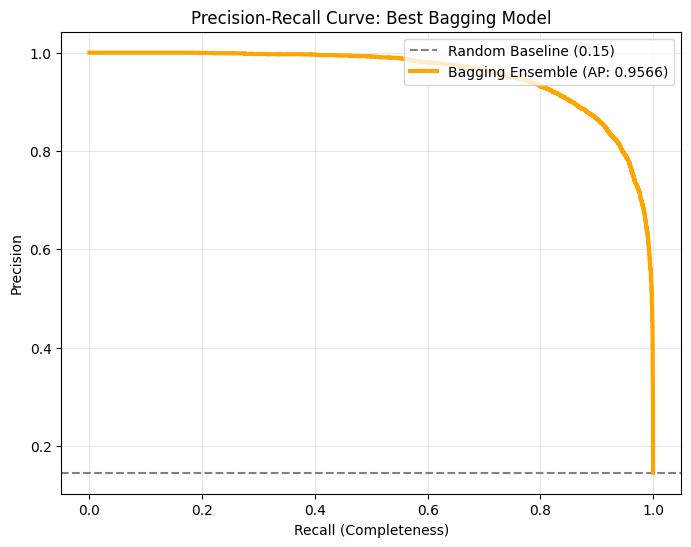

In [ ]:
# Plot
plt.figure(figsize=(8, 6))
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')

plt.plot(recall, precision, color='Orange', lw=3, 
         label=f'Bagging Ensemble (AP: {ap_score_bag:.4f})')

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve: Best Bagging Model')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()


Plot confusion matrix for three with bagging

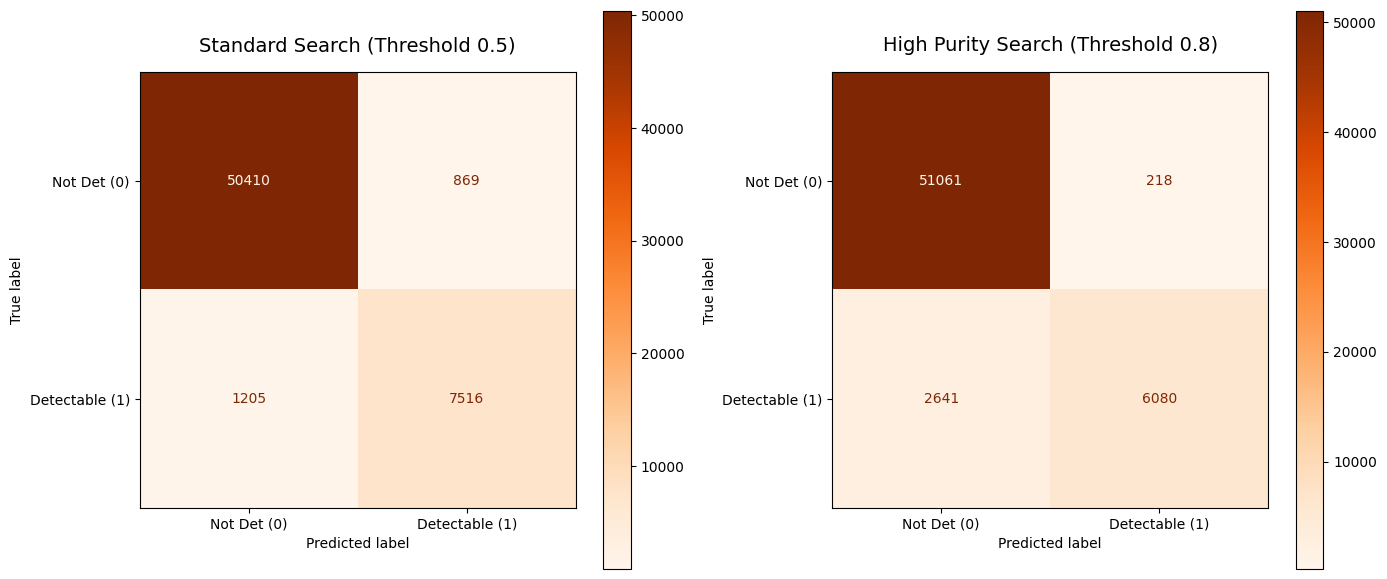

In [ ]:
y_pred_05_bag = (y_prob_bag > 0.5).astype(int)
y_pred_08_bag = (y_prob_bag > 0.8).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05_bag)
cm_08 = confusion_matrix(y_test, y_pred_08_bag)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_05 = ConfusionMatrixDisplay(
    confusion_matrix=cm_05, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)
disp_05.plot(cmap='Oranges', values_format='d', ax=axes[0])
axes[0].set_title('Standard Search (Threshold 0.5)', fontsize=14, pad=15)
axes[0].grid(False)

disp_08 = ConfusionMatrixDisplay(
    confusion_matrix=cm_08, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)
disp_08.plot(cmap='Oranges', values_format='d', ax=axes[1])
axes[1].set_title('High Purity Search (Threshold 0.8)', fontsize=14, pad=15)
axes[1].grid(False)

plt.tight_layout()
plt.show()

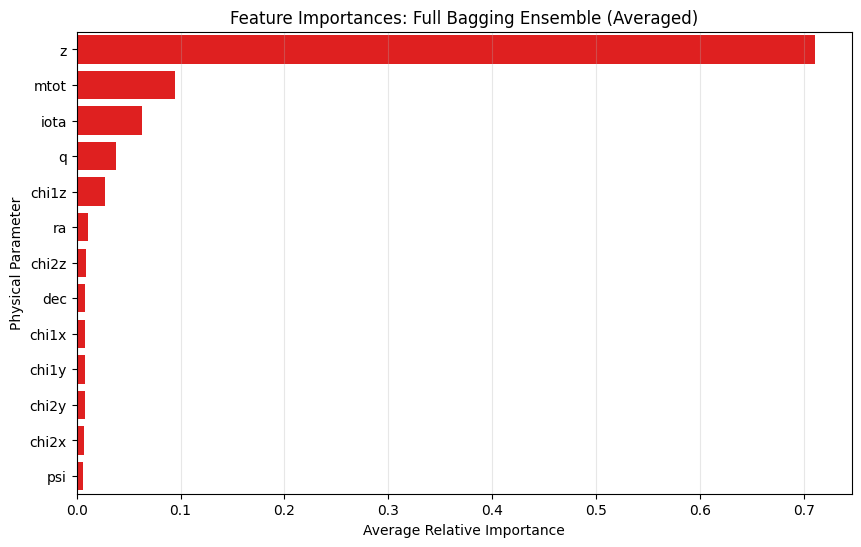

Top 5 important features according to Bagging:
   Feature  Importance
12       z    0.710672
0     mtot    0.094489
10    iota    0.062775
1        q    0.037919
4    chi1z    0.027523


In [ ]:
# Plot the feature importance 
bag_importances = np.mean([tree.feature_importances_ for tree in best_bag_model.estimators_], axis=0)

importance_df_bag = pd.DataFrame({
    'Feature': par_keys,
    'Importance': bag_importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_bag, x='Importance', y='Feature', color="red")
plt.title('Feature Importances: Full Bagging Ensemble (Averaged)')
plt.xlabel('Average Relative Importance')
plt.ylabel('Physical Parameter')
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Top 5 important features according to Bagging:")
print(importance_df_bag.head(5))

In [ ]:
# Extract top 5 names and indices to see if using only them the value of AP score improves
top_5_features_bag_own = importance_df_bag.head(5)['Feature'].tolist()
top_5_indices_bag_own = [par_keys.index(f) for f in top_5_features_bag_own]

# Slice the training and testing sets using only the best 5 features
X_train_bag_final = X_train[:, top_5_indices_bag_own]
X_test_bag_final = X_test[:, top_5_indices_bag_own]

#Downsample for cross validation
X_tune_bag, y_tune_bag = resample(
    X_train_bag_final, y_train, 
    n_samples=len(X_train_bag_final) // 100, 
    stratify=y_train, 
    random_state=42
)


# Setup the Base Tree and Bagging Classifier for tuning
base_dt_tune = DecisionTreeClassifier(class_weight='balanced', random_state=42)
bagging_tune = BaggingClassifier(
    estimator=base_dt_tune, 
    n_estimators=100, 
    random_state=42,
    max_samples=1.0, 
    n_jobs=-1
)

# Setup GridSearchCV 
param_grid_bag_final = {'estimator__max_depth': range(2, 16)}

grid_search_bag_final = GridSearchCV(
    bagging_tune, 
    param_grid_bag_final, 
    cv=5,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

# Fit on the downsampled set
grid_search_bag_final.fit(X_tune_bag, y_tune_bag)

# Extract best results
best_depth_bag_final = grid_search_bag_final.best_params_['estimator__max_depth']
best_score_bag_final = grid_search_bag_final.best_score_
print(f"-> Best max_depth found: {best_depth_bag_final}")
print(f"-> Tuning CV Average Precision: {best_score_bag_final:.4f}")


Fitting 3 folds for each of 14 candidates, totalling 42 fits
-> Best max_depth found: 6
-> Tuning CV Average Precision: 0.9119


Train the best model on the full dataset

In [ ]:
# Build a fresh base tree using the winning depth
base_dt_final = DecisionTreeClassifier(
    max_depth=best_depth_bag_final, 
    class_weight='balanced', 
    random_state=42
)

# Build the final bagging model
best_bag_final_model = BaggingClassifier(
    estimator=base_dt_final, 
    n_estimators=100, 
    random_state=42,
    max_samples=1.0, 
    n_jobs=-1
)

best_bag_final_model.fit(X_train_bag_final, y_train)

y_prob_bag_final_top5 = best_bag_final_model.predict_proba(X_test_bag_final)[:, 1]
#y_pred_bag_final = best_bag_final_model.predict(X_test_bag_final)

ap_score_bag_final = average_precision_score(y_test, y_prob_bag_final_top5)
precision_bag_f, recall_bag_f, _ = precision_recall_curve(y_test, y_prob_bag_final_top5)



Plot PR curve

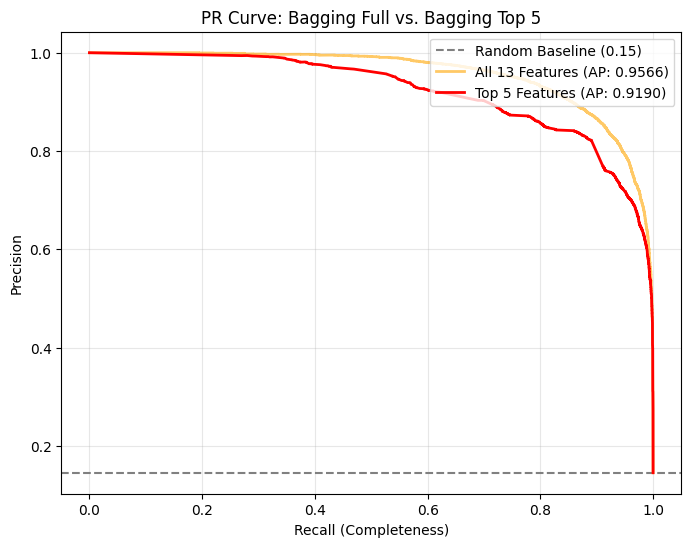

In [ ]:
# Plot 
plt.figure(figsize=(8, 6))
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')
plt.plot(recall, precision, label=f'All 13 Features (AP: {ap_score_bag:.4f})', color='orange', alpha=0.6, lw=2)
plt.plot(recall_bag_f, precision_bag_f, label=f'Top 5 Features (AP: {ap_score_bag_final:.4f})', color='red', lw=2)

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')
plt.title('PR Curve: Bagging Full vs. Bagging Top 5')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

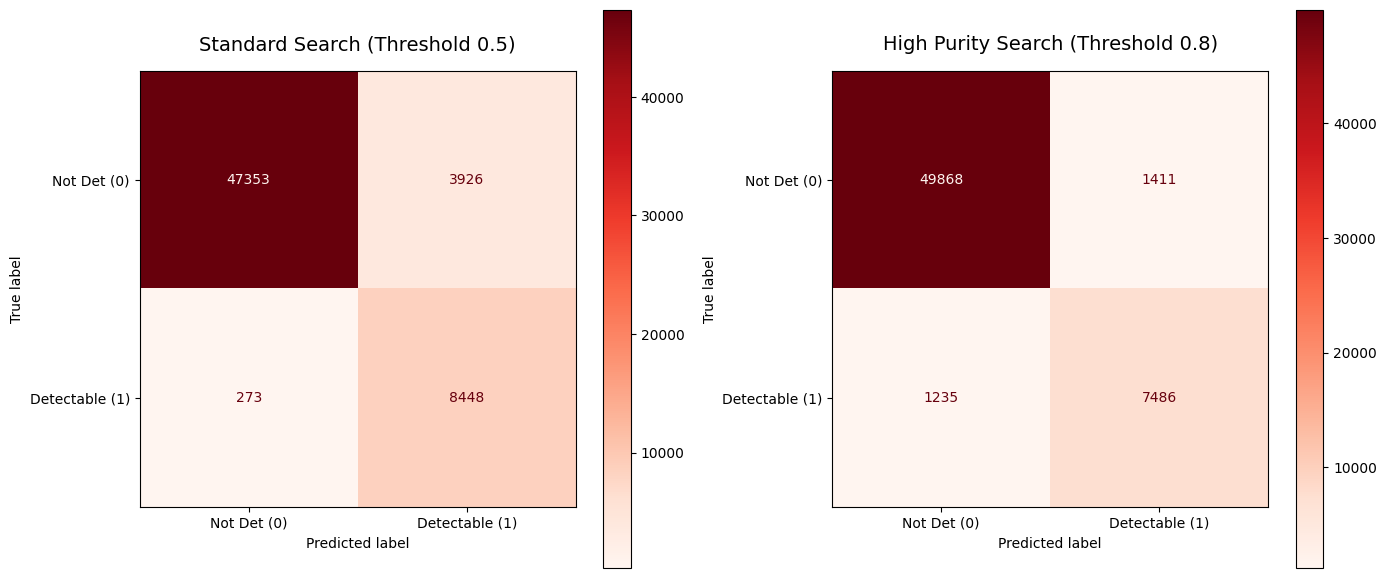

In [ ]:
y_pred_05_bag_top5 = (y_prob_bag_final_top5 > 0.5).astype(int)
y_pred_08_bag_top5 = (y_prob_bag_final_top5 > 0.8).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05_bag_top5)
cm_08 = confusion_matrix(y_test, y_pred_08_bag_top5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_05 = ConfusionMatrixDisplay(
    confusion_matrix=cm_05, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)
disp_05.plot(cmap='Reds', values_format='d', ax=axes[0])
axes[0].set_title('Standard Search (Threshold 0.5)', fontsize=14, pad=15)
axes[0].grid(False)

disp_08 = ConfusionMatrixDisplay(
    confusion_matrix=cm_08, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)
disp_08.plot(cmap='Reds', values_format='d', ax=axes[1])
axes[1].set_title('High Purity Search (Threshold 0.8)', fontsize=14, pad=15)
axes[1].grid(False)

plt.tight_layout()
plt.show()

Now try random forest classifier

In [ ]:
# setup downsample for the hyperpar tuning

X_train_down_rf, y_train_down_rf = resample(
    X_train, y_train, 
    n_samples=len(X_train) // 100, 
    stratify=y_train, 
    random_state=42
)


rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# hyperparameters
param_grid_rf = { 'max_depth': range (1,16), 'n_estimators': [100], 'min_samples_leaf': [10]}

grid_search_rf = GridSearchCV(rf_clf, param_grid_rf, cv=5, scoring='average_precision', verbose=1)
grid_search_rf.fit(X_train_down_rf, y_train_down_rf)


results_rf = grid_search_rf.cv_results_
best_params_rf = grid_search_rf.best_params_
best_rf_model = grid_search_rf.best_estimator_

print(f"Best Parameters: {best_params_rf}")
print(f"Best Mean Average Precision: {grid_search_rf.best_score_:.4f}")





Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters: {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 100}
Best Mean Average Precision: 0.9011


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


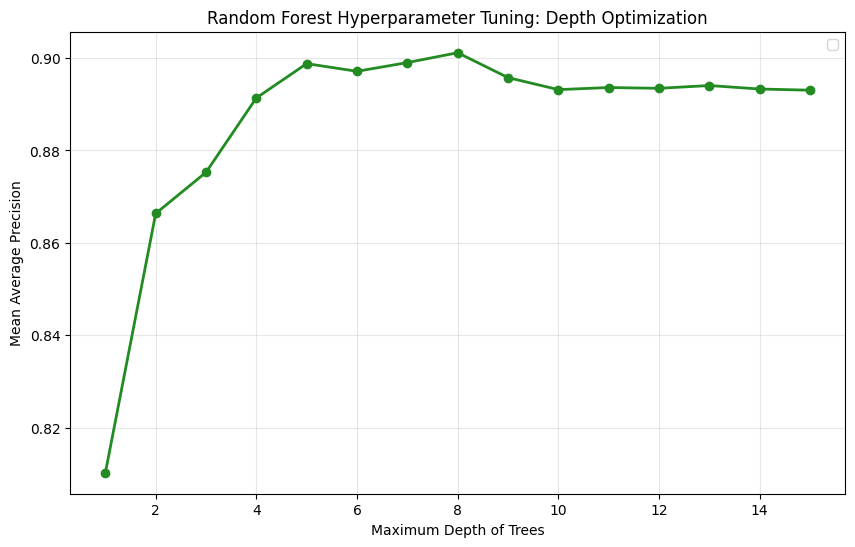

In [ ]:
#plot
scores = results_rf['mean_test_score']
depths = list(range(1, 16))

plt.figure(figsize=(10, 6))
plt.plot(depths, scores, marker='o', lw=2, color='forestgreen')

plt.xlabel('Maximum Depth of Trees')
plt.ylabel('Mean Average Precision')
plt.title('Random Forest Hyperparameter Tuning: Depth Optimization')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Plot PR curve for the best model parameters

In [ ]:
best_rf_model = RandomForestClassifier(
    max_depth=best_params_rf['max_depth'],
    n_estimators=best_params_rf['n_estimators'],
    min_samples_leaf=best_params_rf['min_samples_leaf'],
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train on the entire training set
best_rf_model.fit(X_train, y_train)

# Best model Precision Recall
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf_model.predict(X_test)

ap_score_rf = average_precision_score(y_test, y_prob_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

Plot PR curve

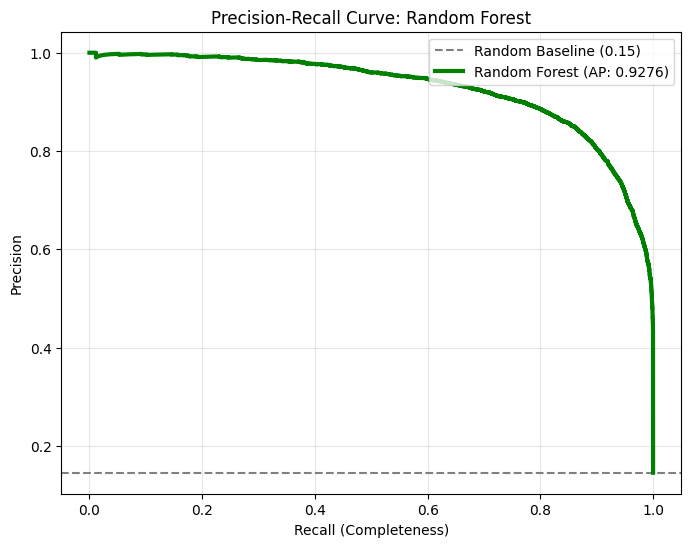

In [ ]:
# Plot Precision Recall curve
plt.figure(figsize=(8, 6))
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')

plt.plot(recall_rf, precision_rf, color='green', lw=3, 
         label=f'Random Forest (AP: {ap_score_rf:.4f})')

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve: Random Forest')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()



Plot the confusion matrix

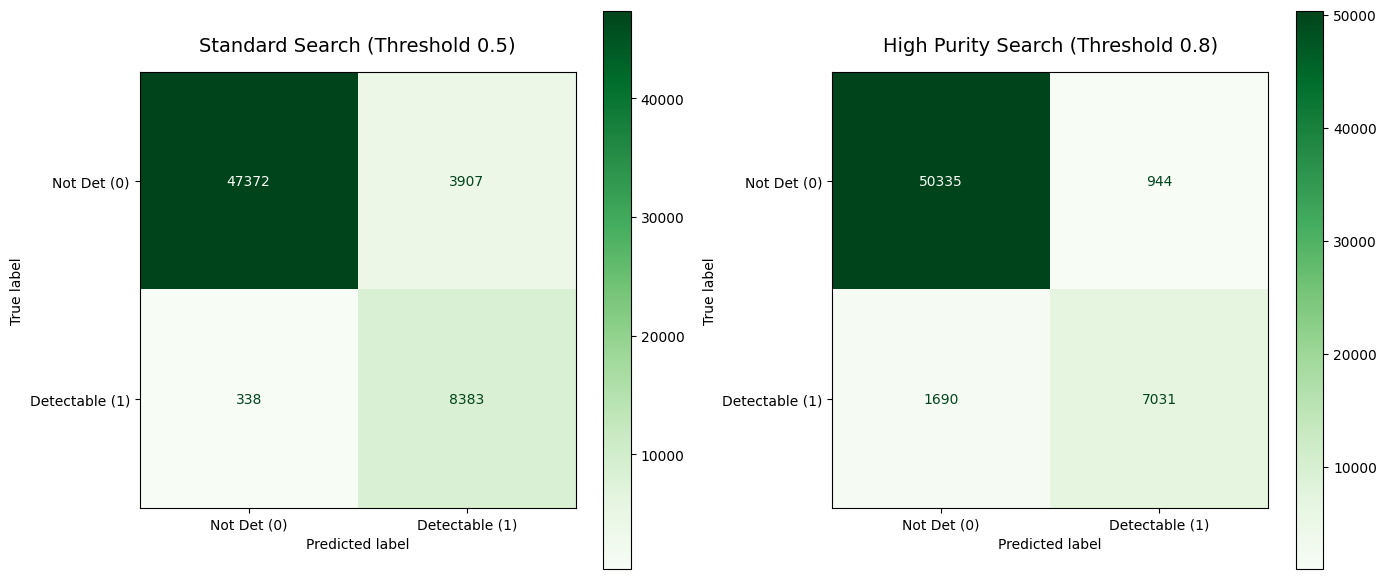

In [ ]:
y_pred_05_rf = (y_prob_rf > 0.5).astype(int)
y_pred_08_rf = (y_prob_rf > 0.8).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05_rf)
cm_08 = confusion_matrix(y_test, y_pred_08_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_05 = ConfusionMatrixDisplay(
    confusion_matrix=cm_05, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)
disp_05.plot(cmap='Greens', values_format='d', ax=axes[0])
axes[0].set_title('Standard Search (Threshold 0.5)', fontsize=14, pad=15)
axes[0].grid(False)

disp_08 = ConfusionMatrixDisplay(
    confusion_matrix=cm_08, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)
disp_08.plot(cmap='Greens', values_format='d', ax=axes[1])
axes[1].set_title('High Purity Search (Threshold 0.8)', fontsize=14, pad=15)
axes[1].grid(False)

plt.tight_layout()
plt.show()

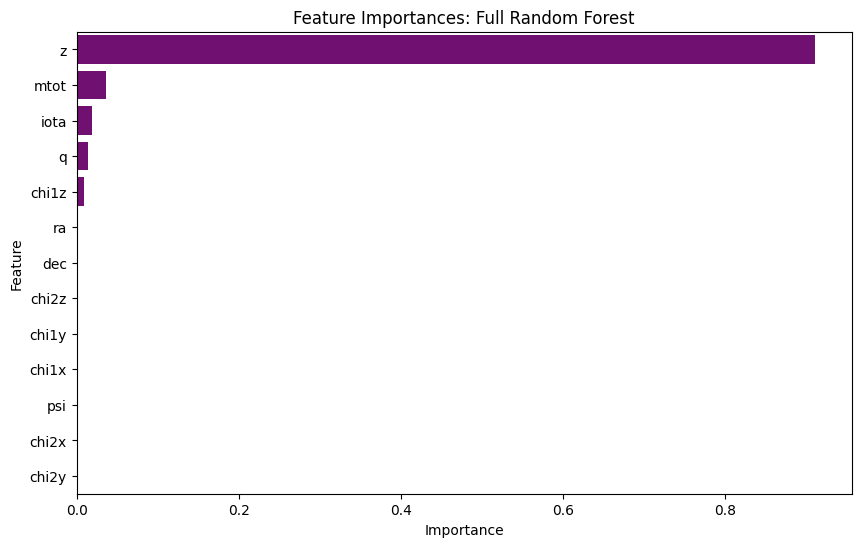

In [ ]:
# Use the feature importances from the best_rf_model we just trained
importance_df_rf = pd.DataFrame({
    'Feature': par_keys,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_rf, x='Importance', y='Feature', color='purple' )
plt.title('Feature Importances: Full Random Forest')
plt.show()

# Extract top 5 names
top_5_features = importance_df_rf.head(5)['Feature'].tolist()
top_5_indices = [par_keys.index(f) for f in top_5_features]

# Slice the training and testing sets
X_train_top5 = X_train[:, top_5_indices]
X_test_top5 = X_test[:, top_5_indices]

In [ ]:
# Initialize new Random Forest using only best 5 features
rf_top5_clf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

#Downsample for cross validation
X_tune_rf, y_tune_rf = resample(
    X_train_top5, y_train, 
    n_samples=len(X_train_top5) // 100, 
    stratify=y_train, 
    random_state=42
)

# Define a focused Grid Search
param_grid_top5 = {
    'max_depth': range(1,16),
    'n_estimators': [100],
    'min_samples_leaf': [10] 
}

# Execute CV
grid_search_top5 = GridSearchCV(
    rf_top5_clf, 
    param_grid_top5, 
    cv=5, 
    scoring='average_precision', 
    verbose=1
)

grid_search_top5.fit(X_tune_rf, y_tune_rf)

# Extract Best Model
best_params_top5 = grid_search_top5.best_params_

print(f"\nBest Params (Top 5): {best_params_top5}")
print(f"CV Average Precision: {grid_search_top5.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Params (Top 5): {'max_depth': 11, 'min_samples_leaf': 10, 'n_estimators': 100}
CV Average Precision: 0.9085


In [ ]:
# Filter the data
X_train_top5 = X_train[:, top_5_indices]
X_test_top5 = X_test[:, top_5_indices]


best_rf_top5_model = RandomForestClassifier(
    max_depth=best_params_top5['max_depth'],
    n_estimators=best_params_top5['n_estimators'],
    min_samples_leaf=best_params_top5['min_samples_leaf'],
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_rf_top5_model.fit(X_train_top5, y_train)

y_prob_top5_rf = best_rf_top5_model.predict_proba(X_test_top5)[:, 1]
y_pred_top5 = best_rf_top5_model.predict(X_test_top5)

ap_score_top5_rf = average_precision_score(y_test, y_prob_top5_rf)
precision_top5, recall_top5, _ = precision_recall_curve(y_test, y_prob_top5_rf)



Plot the PR curves

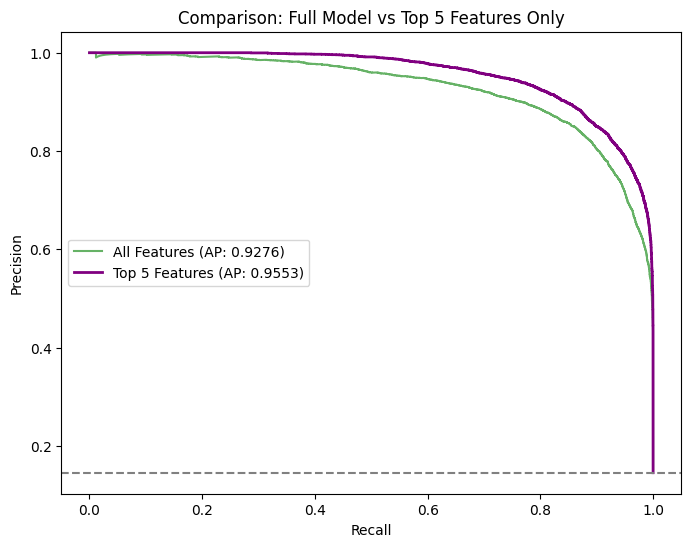

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label=f'All Features (AP: {ap_score_rf:.4f})', color='green', alpha=0.6)
plt.plot(recall_top5, precision_top5, label=f'Top 5 Features (AP: {ap_score_top5_rf:.4f})', color='purple', lw=2)
plt.axhline(y=baseline, color='gray', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparison: Full Model vs Top 5 Features Only')
plt.legend()
plt.show()

Confusion Matrix

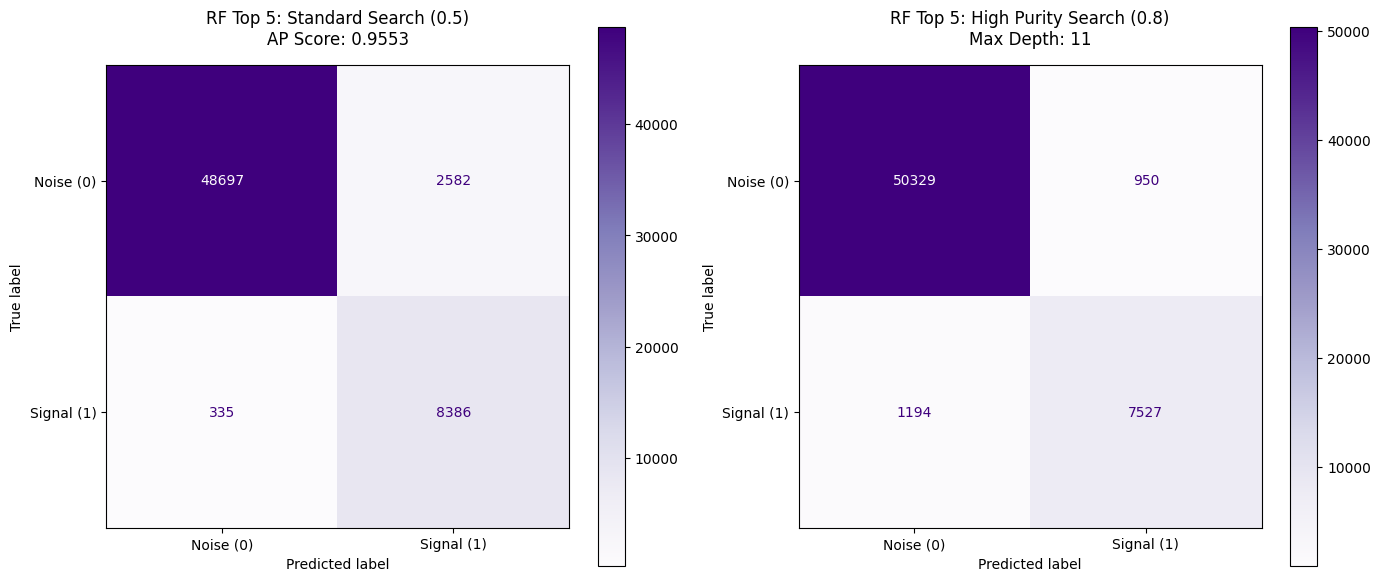

In [ ]:

y_pred_top5_05 = (y_prob_top5_rf > 0.5).astype(int)
y_pred_top5_08 = (y_prob_top5_rf > 0.8).astype(int)


cm_top5_05 = confusion_matrix(y_test, y_pred_top5_05)
cm_top5_08 = confusion_matrix(y_test, y_pred_top5_08)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


disp_05 = ConfusionMatrixDisplay(
    confusion_matrix=cm_top5_05, 
    display_labels=["Noise (0)", "Signal (1)"]
)
disp_05.plot(cmap='Purples', values_format='d', ax=axes[0]) # Using Purples to distinguish from DT
axes[0].set_title(f'RF Top 5: Standard Search (0.5)\nAP Score: {ap_score_top5_rf:.4f}', fontsize=12, pad=15)
axes[0].grid(False)


disp_08 = ConfusionMatrixDisplay(
    confusion_matrix=cm_top5_08, 
    display_labels=["Noise (0)", "Signal (1)"]
)
disp_08.plot(cmap='Purples', values_format='d', ax=axes[1])
axes[1].set_title(f'RF Top 5: High Purity Search (0.8)\nMax Depth: {best_params_top5["max_depth"]}', fontsize=12, pad=15)
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [ ]:
summary_data = {
    "Model Architecture": [
        "Decision Tree (All 13 Features)",
        "Bagging Ensemble (All 13 Features)",
        "Bagging Ensemble (Top 5 Features)",
        "Random Forest (All 13 Features)",
        "Random Forest (Top 5 Features)"
    ],
    "PR-AUC Score": [
        ap_score_dt,
        ap_score_bag,
        ap_score_bag_final,
        ap_score_rf,
        ap_score_top5_rf
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(by="PR-AUC Score", ascending=False).reset_index(drop=True)

# 3. Print a clean text table
print("\n" + "="*60)
print(f"{'FINAL MODEL PERFORMANCE SUMMARY (PR-AUC)':^60}")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60 + "\n")


          FINAL MODEL PERFORMANCE SUMMARY (PR-AUC)          
                Model Architecture  PR-AUC Score
Bagging Ensemble (All 13 Features)      0.956550
    Random Forest (Top 5 Features)      0.955311
   Random Forest (All 13 Features)      0.927589
 Bagging Ensemble (Top 5 Features)      0.918998
   Decision Tree (All 13 Features)      0.907965

